<h1 style="text-align:center; color:#1ABC9C;">
    Hand Sign Language Recognition (Pose Estimation)
</h1>

<hr>

<p style="text-align:center; font-size:18px;">
    Using MediaPipe, Machine Learning CLassifiers
</p>

<h2>
<a href="https://www.bing.com/images/search?view=detailV2&ccid=yHEX1RmT&id=7AE04325B34660EAD57038ABEB0FEAA1288E7262&thid=OIP.yHEX1RmTeX_3suZEwHUAKgHaHa&mediaurl=https%3a%2f%2fpng.pngtree.com%2fpng-clipart%2f20190516%2foriginal%2fpngtree-aphabets-by-fingers-from-american-sign-language-png-image_3714747.jpg&cdnurl=https%3a%2f%2fth.bing.com%2fth%2fid%2fR.c87117d51993797ff7b2e644c075002a%3frik%3dYnKOKKHqD%252burOA%26pid%3dImgRaw%26r%3d0&exph=1200&expw=1200&q=sign+language&FORM=IRPRST&ck=8ACEDC3723E3D8F26F0B14C40D504AFB&selectedIndex=2&itb=0">For Sign Language Click Here ..</a> </h2>

## Install Dependencies

In [1]:
%pip install ultralytics mediapipe gradio scikit-learn seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.7 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.1 MB 453.2 kB/s eta 0:00:17
   --- -

## Unzipping Dataset

In [ ]:
!unzip archive.zip -d ./Dataset

Archive:  archive.zip
  inflating: ./Dataset/Hand_Sign_Language_A.mp4  
  inflating: ./Dataset/Hand_Sign_Language_B.mp4  
  inflating: ./Dataset/Hand_Sign_Language_F.mp4  
  inflating: ./Dataset/Hand_Sign_Language_S.mp4  


## Import Libraries

In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import mediapipe as mp
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
import time
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import  LogisticRegression ,RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier ,StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,ComplementNB,BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier,BaggingClassifier, GradientBoostingClassifier, VotingClassifier , StackingClassifier ,AdaBoostClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)

c:\Users\alash\OneDrive\Desktop\cv\task3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check Library Content

In [27]:
import mediapipe as mp

print(dir(mp))

['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


## Install Mediapipe Model

In [ ]:
!curl -o hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0  7.45M   0   1821   0      0   1771      0 1:13:35   00:01 1:13:34   1780
 12  7.45M  12 936.6k   0      0 461.8k      0   00:16   00:02   00:14 463.0k
 27  7.45M  27  2.05M   0      0 694.1k      0   00:11   00:03   00:08 695.2k
 43  7.45M  43  3.25M   0      0 827.7k      0   00:09   00:04   00:05 828.6k
 59  7.45M  59  4.42M   0      0 901.5k      0   00:08   00:05   00:03 902.4k
 75  7.45M  75  5.64M   0      0 958.8k      0   00:07   00:06   00:01  1.12M
 88  7.45M  88  6.59M   0      0 961.3k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.9k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.9k      0   00:07   00:07          1.13M
100  7.45M 100  7.45M   0      0 985.8k      0   00:07   00:07 

# Manipulate Dataset (Data Preprocessing)

In [2]:
# -----------------------------
# Dataset
# -----------------------------
dataset_dir = './Dataset'
videos = os.listdir(dataset_dir)

classes = [v.replace("Hand_Sign_Language_", "").split('.')[0] for v in videos]

# FIX: label map must be based on class, not filename
label_map = {video_name: class_num for class_num, video_name in enumerate(videos)}

print(classes)
print(label_map)

# -----------------------------
# MediaPipe setup
# -----------------------------
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

model_path = "hand_landmarker.task"

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=1
)

landmarker = HandLandmarker.create_from_options(options)

# -----------------------------
# CONSTANTS
# -----------------------------
MAX_HANDS = 1
LM_SIZE = 21 * 2 #(x, y, z) for each of the 21 landmarks
FEATURE_SIZE = MAX_HANDS * LM_SIZE

# -----------------------------
# Extract frames → CSV rows
# -----------------------------
def extract_video_frames(video_name, skip_rate=1):

    #  CREATE NEW LANDMARKER HERE (means it know there is new video with new hand signs)
    landmarker = HandLandmarker.create_from_options(options)

    path = os.path.join(dataset_dir, video_name)
    cap = cv2.VideoCapture(path)

    features = []
    label = label_map[video_name]

    print(f"Processing {video_name} - Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")

    frame_idx = 0
    timestamp = 0
    time_step = 33

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % skip_rate != 0: # skip to ensure all frames has difference
            frame_idx += 1
            timestamp += time_step
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        #  NOW SAFE (fresh landmarker)
        result = landmarker.detect_for_video(mp_image, timestamp)
        timestamp += time_step

        hands_data = [[0] * LM_SIZE for _ in range(MAX_HANDS)]

        if result.hand_landmarks:
            for i, hand in enumerate(result.hand_landmarks[:MAX_HANDS]): # If u need more than 1 hand, increase MAX_HANDS and adjust the code accordingly
                lm_list = []
                for lm in hand:
                    lm_list.extend([lm.x, lm.y]) # add new  x, y  to next column or feature from 42 But Better to decrease dimensionality by 2*21 instead of 3*21 (x, y, z) because z is not very useful for 2D video data
                hands_data[i] = lm_list

        frame_vector = []
        for h in hands_data:
            frame_vector.extend(h)

        features.append(frame_vector)

        frame_idx += 1

    cap.release()

    return features, label

['A', 'B', 'F', 'S']
{'Hand_Sign_Language_A.mp4': 0, 'Hand_Sign_Language_B.mp4': 1, 'Hand_Sign_Language_F.mp4': 2, 'Hand_Sign_Language_S.mp4': 3}


## Creating CSV File

In [3]:
# -----------------------------
# BUILD CSV DATASET
# -----------------------------
X = []
y = []

for video in videos:
    frames, label = extract_video_frames(video)

    for f in frames:
        X.append(f)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------------
# SAVE CSV
# -----------------------------
df = pd.DataFrame(X)
df.columns = [f"f{i}" for i in range(FEATURE_SIZE)]
df["label"] = y

df.to_csv("hand_sign_frame_dataset.csv", index=False)

print("Saved: hand_sign_frame_dataset.csv")

Processing Hand_Sign_Language_A.mp4 - Total frames: 743
Processing Hand_Sign_Language_B.mp4 - Total frames: 803
Processing Hand_Sign_Language_F.mp4 - Total frames: 759
Processing Hand_Sign_Language_S.mp4 - Total frames: 678
X shape: (2983, 42)
y shape: (2983,)
Saved: hand_sign_frame_dataset.csv


##  Hand Sign Language Dataset Description

### Overview
This dataset is generated from video recordings of hand sign gestures using **MediaPipe Hand Landmarker**.  
Each row represents a **single video frame**, transformed into a numerical feature vector suitable for machine learning models.

---

###  Feature Representation

- Each frame contains **21 hand landmarks**
- Each landmark has **3 coordinates**:
  - `x` → normalized horizontal position
  - `y` → normalized vertical position
  - `z` → relative depth

 Total features per frame:


---

###  Dataset Structure

| Component | Description |
|----------|------------|
| `f0 → f62` | Flattened landmark coordinates (x, y, z for each point) |
| `label` | Target class (hand sign category) |

- Total columns: **64**
- Feature columns: **63**
- Label column: **1**

---

###  Labels

Each label corresponds to a specific hand sign:

| Label | Class |
|------|------|
| 0 | A |
| 1 | B |
| 2 | F |
| 3 | S |

---

###  Data Processing Pipeline

1. Videos are loaded from the dataset directory  
2. Frames are extracted using OpenCV  
3. Every *N-th frame* is sampled to reduce redundancy  
4. MediaPipe detects hand landmarks per frame  
5. Landmarks are flattened into a feature vector  
6. Frames are labeled based on the source video  
7. All data is stored in a CSV file  

---

###  Key Characteristics

- **Data Type:** Numerical (float32)
- **Normalization:** Coordinates are normalized in range `[0, 1]`
- **Missing Hands:** Represented as zero vectors
- **Temporal Info:** Not included (frame-based dataset)

---

###  Use Cases

This dataset is suitable for: 21 landmarks × 3 coordinates = 63 features

- Hand gesture classification
- Traditional ML models (SVM, Random Forest, XGBoost)
- Deep learning models (MLP, CNN, Transformer with sequences)
- Real-time sign language recognition systems

---

###  Notes

- The dataset is **frame-independent**, meaning temporal relationships between frames are not preserved.
- For sequence-based models (e.g., LSTM), a different dataset format (video sequences) is required.

## Dataset Description

In [69]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f33,f34,f35,f36,f37,f38,f39,f40,f41,label
0,0.704743,0.733471,0.494864,0.666469,0.370341,0.554361,0.322758,0.451897,0.276544,0.374874,...,0.529570,0.872433,0.492718,0.790568,0.453768,0.743217,0.522555,0.777484,0.536710,0
1,0.704224,0.730582,0.496323,0.662712,0.379908,0.548232,0.330295,0.448827,0.279814,0.373618,...,0.530205,0.858581,0.490628,0.785077,0.445435,0.735041,0.512130,0.765392,0.532525,0
2,0.701985,0.731364,0.497925,0.662110,0.381779,0.550310,0.333663,0.451827,0.283752,0.374450,...,0.527439,0.860324,0.491902,0.783319,0.443898,0.730582,0.510025,0.758881,0.532304,0
3,0.701606,0.732273,0.496582,0.662119,0.379584,0.548017,0.331082,0.448751,0.287282,0.370893,...,0.527096,0.859204,0.491106,0.783772,0.444695,0.729542,0.510664,0.757395,0.531976,0
4,0.700071,0.732689,0.495103,0.663736,0.377328,0.551693,0.326060,0.452988,0.279153,0.375449,...,0.527344,0.854873,0.489684,0.778088,0.445516,0.725566,0.510539,0.753957,0.530271,0


In [70]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,2983.0,0.601725,0.135929,0.000000,0.530941,0.612037,0.691981,1.026208
f1,2983.0,0.724501,0.149477,0.000000,0.641062,0.719938,0.816091,1.164231
f2,2983.0,0.518616,0.205020,0.000000,0.383900,0.471232,0.661401,1.133952
f3,2983.0,0.648130,0.143838,0.000000,0.564046,0.646263,0.736796,1.090723
f4,2983.0,0.446977,0.269302,-0.050830,0.248861,0.352671,0.695117,1.151427
f5,2983.0,0.542506,0.137011,0.000000,0.462915,0.548232,0.628469,0.977887
f6,2983.0,0.405902,0.255104,-0.162751,0.220843,0.332849,0.616893,1.111593
f7,2983.0,0.447623,0.134462,0.000000,0.366355,0.451070,0.532507,0.920810
f8,2983.0,0.397545,0.221709,-0.246817,0.239221,0.370340,0.572249,1.043969
f9,2983.0,0.390052,0.133460,0.000000,0.308558,0.393525,0.470071,0.927247


In [4]:
df['label'].value_counts()


label
1    803
2    759
0    743
3    678
Name: count, dtype: int64

### Remove Duplicates

In [72]:
df.duplicated().sum()

np.int64(32)

In [73]:
df = df.drop_duplicates(keep='first')

### Missing Data

In [74]:
df.isnull().sum()

f0       0
f1       0
f2       0
f3       0
f4       0
f5       0
f6       0
f7       0
f8       0
f9       0
f10      0
f11      0
f12      0
f13      0
f14      0
f15      0
f16      0
f17      0
f18      0
f19      0
f20      0
f21      0
f22      0
f23      0
f24      0
f25      0
f26      0
f27      0
f28      0
f29      0
f30      0
f31      0
f32      0
f33      0
f34      0
f35      0
f36      0
f37      0
f38      0
f39      0
f40      0
f41      0
label    0
dtype: int64

In [75]:
df['label'].value_counts()

label
1    789
2    759
0    743
3    660
Name: count, dtype: int64

### Outliers

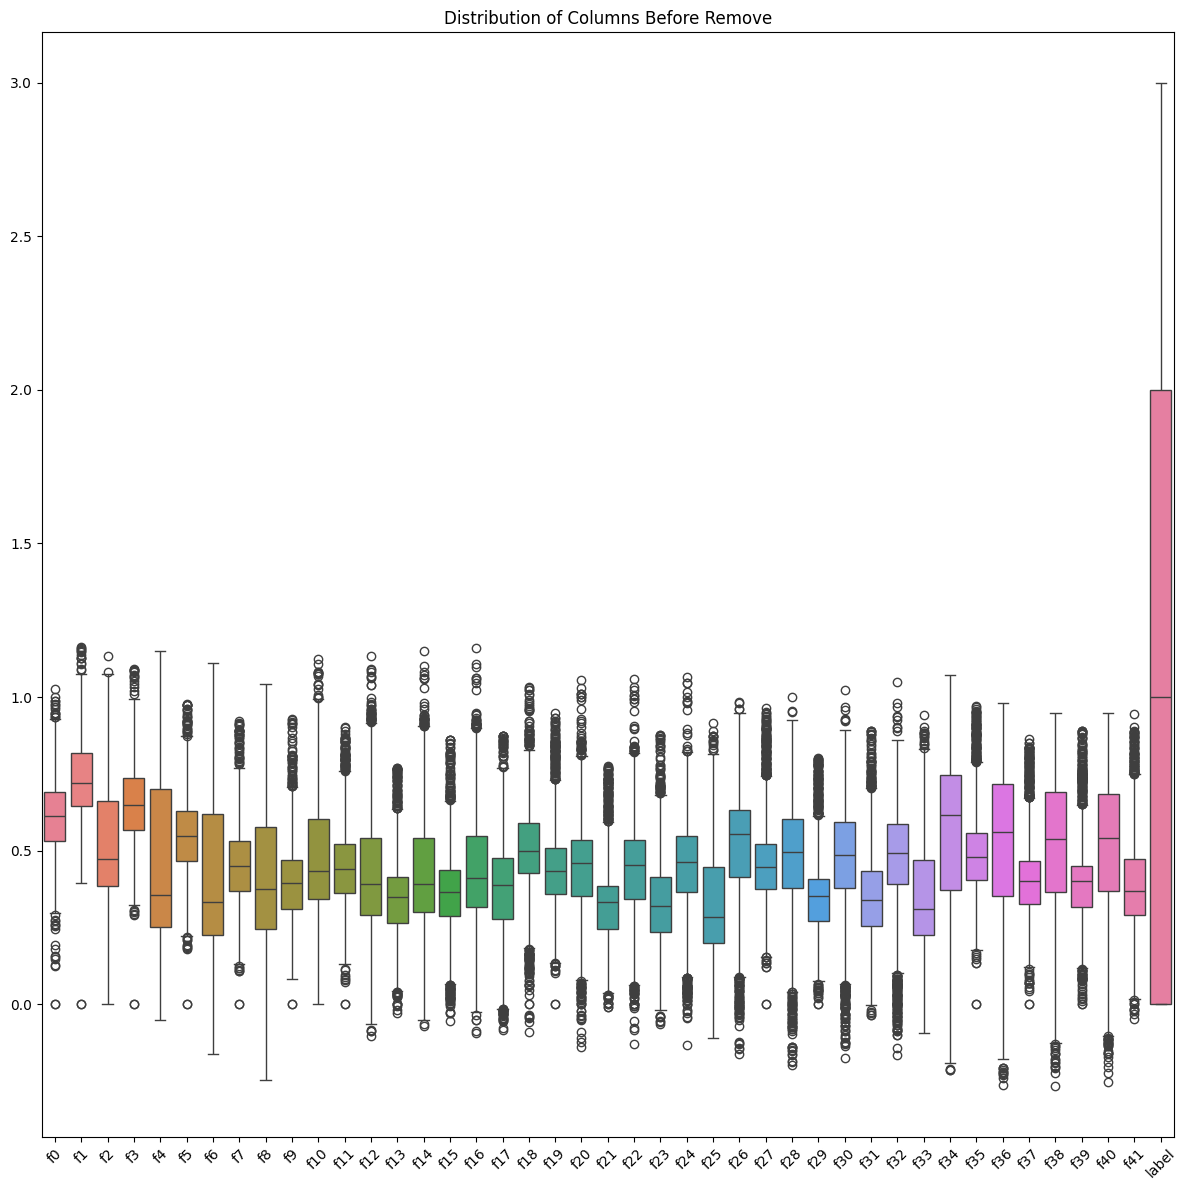

In [76]:
plt.figure(figsize=(12,12))
sns.boxplot(data=df[df.columns])
plt.title("Distribution of Columns Before Remove")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bi Varate Analysis (Relationship Between two Variables)

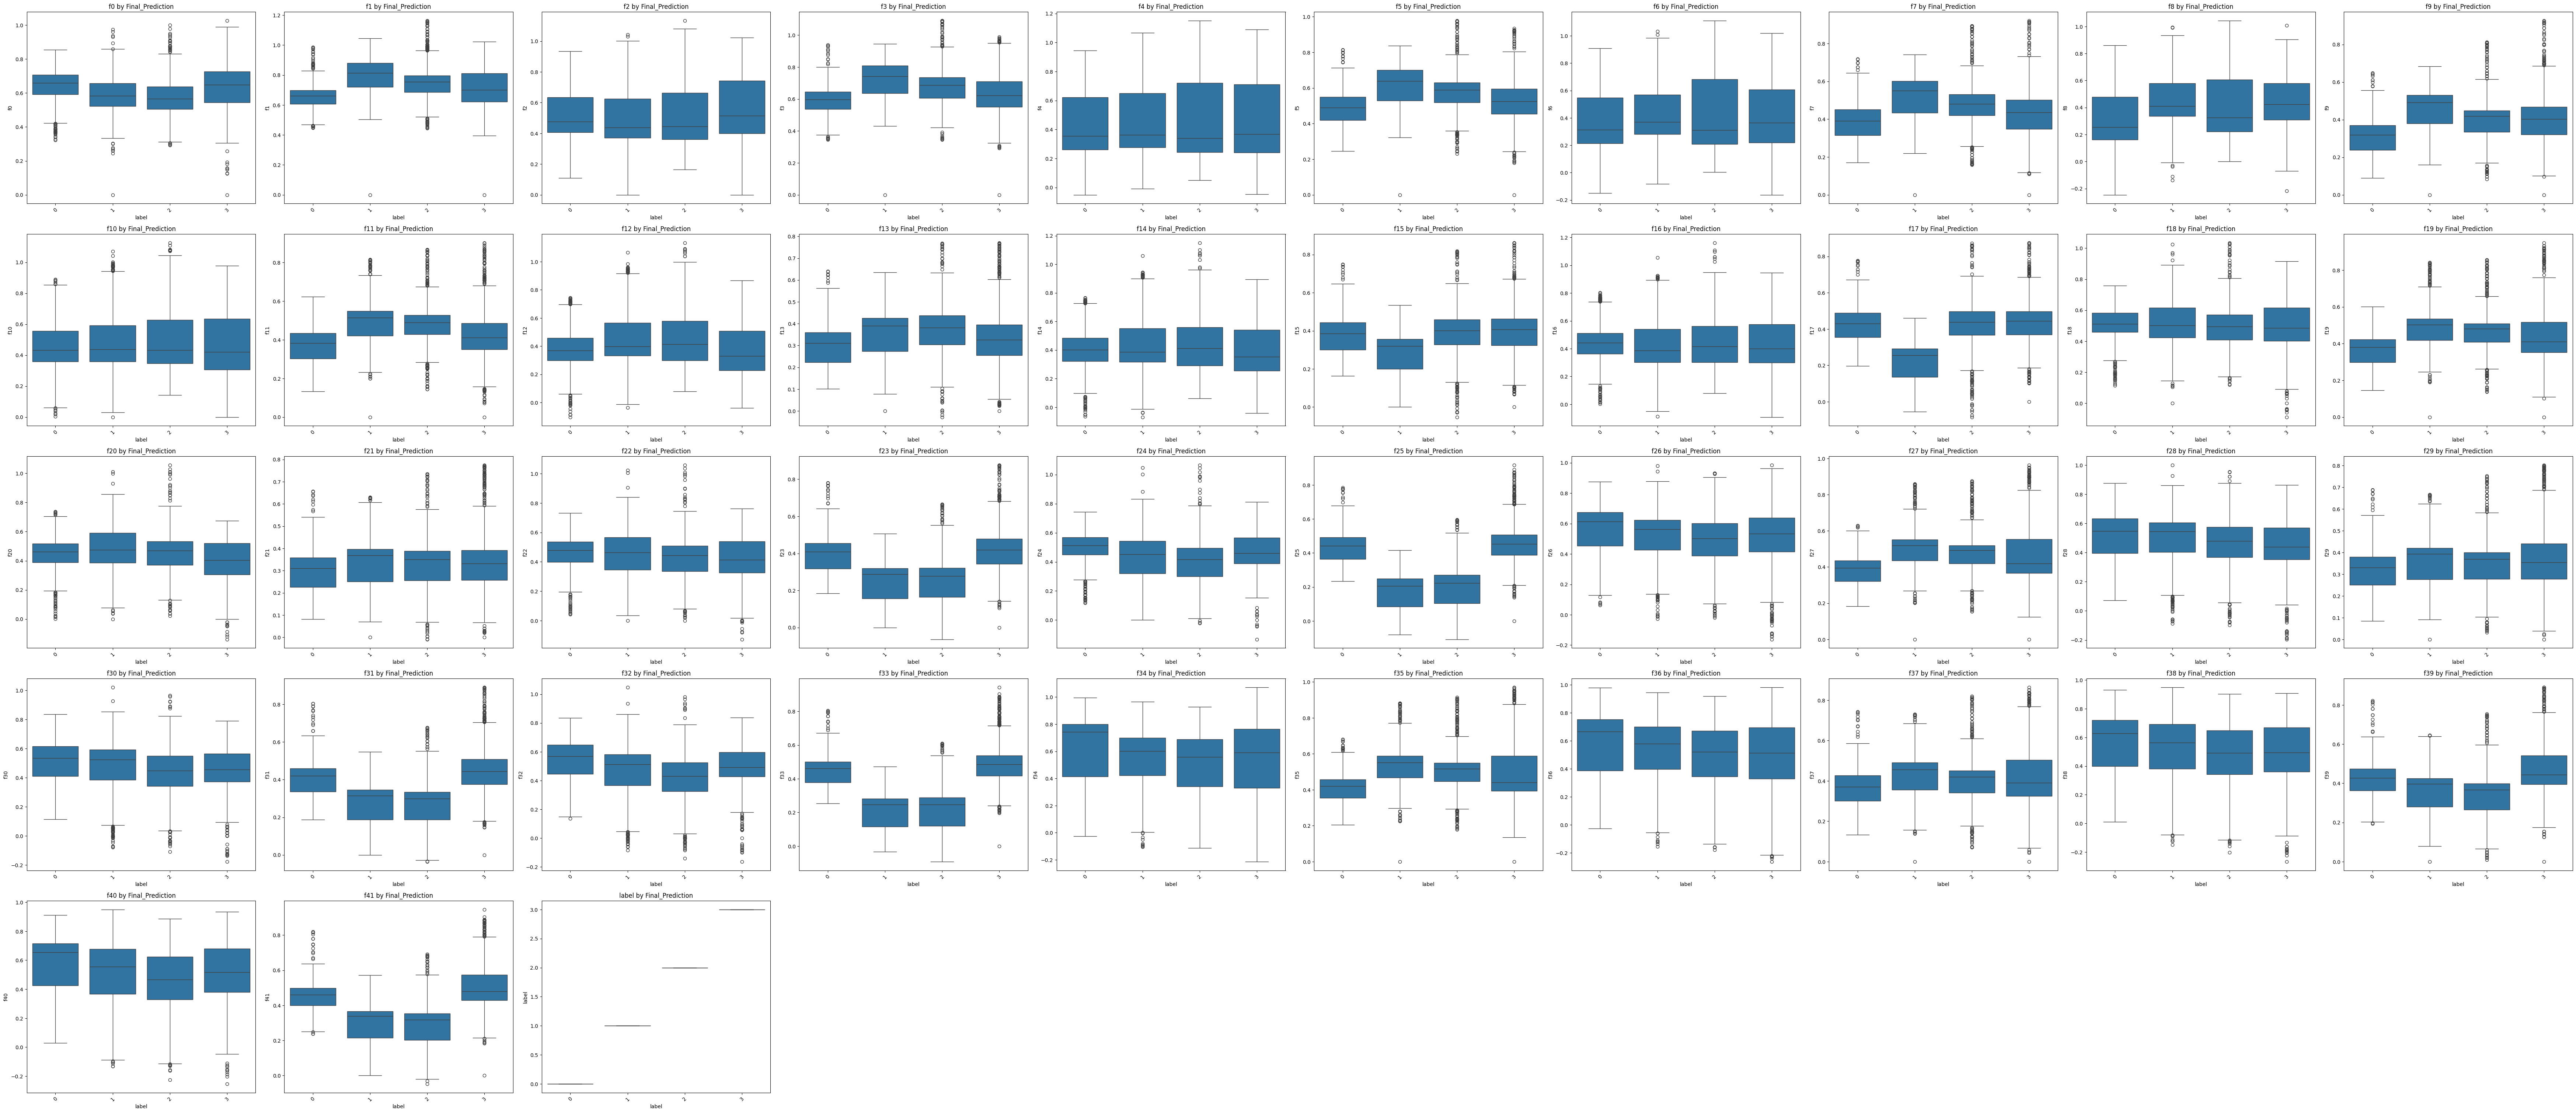

In [77]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(70, 60))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(10,10, i)  
    sns.boxplot(x='label', y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} by Final_Prediction')
plt.tight_layout()
plt.show()

## Data Cleaning

`Data Is Cleaned..`

## Splitting

In [5]:
data_input = df.drop(columns='label')
data_output = df['label']
data_input.shape

(2983, 42)

In [6]:

from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    data_input, data_output, test_size=0.10, random_state=0, stratify=data_output, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=0, stratify=y, shuffle=True
)

### Feature Scaling / Normalization

In [7]:
from sklearn.preprocessing import StandardScaler ,RobustScaler,MinMaxScaler

scaler = RobustScaler() # robust with outliers, standard for normal distribution, minmax for normalization

X_train = scaler.fit_transform(X_train)  # fit ONLY on train
X_test = scaler.transform(X_test)        # transform test
X_val = scaler.transform(X_val)          # transform validation

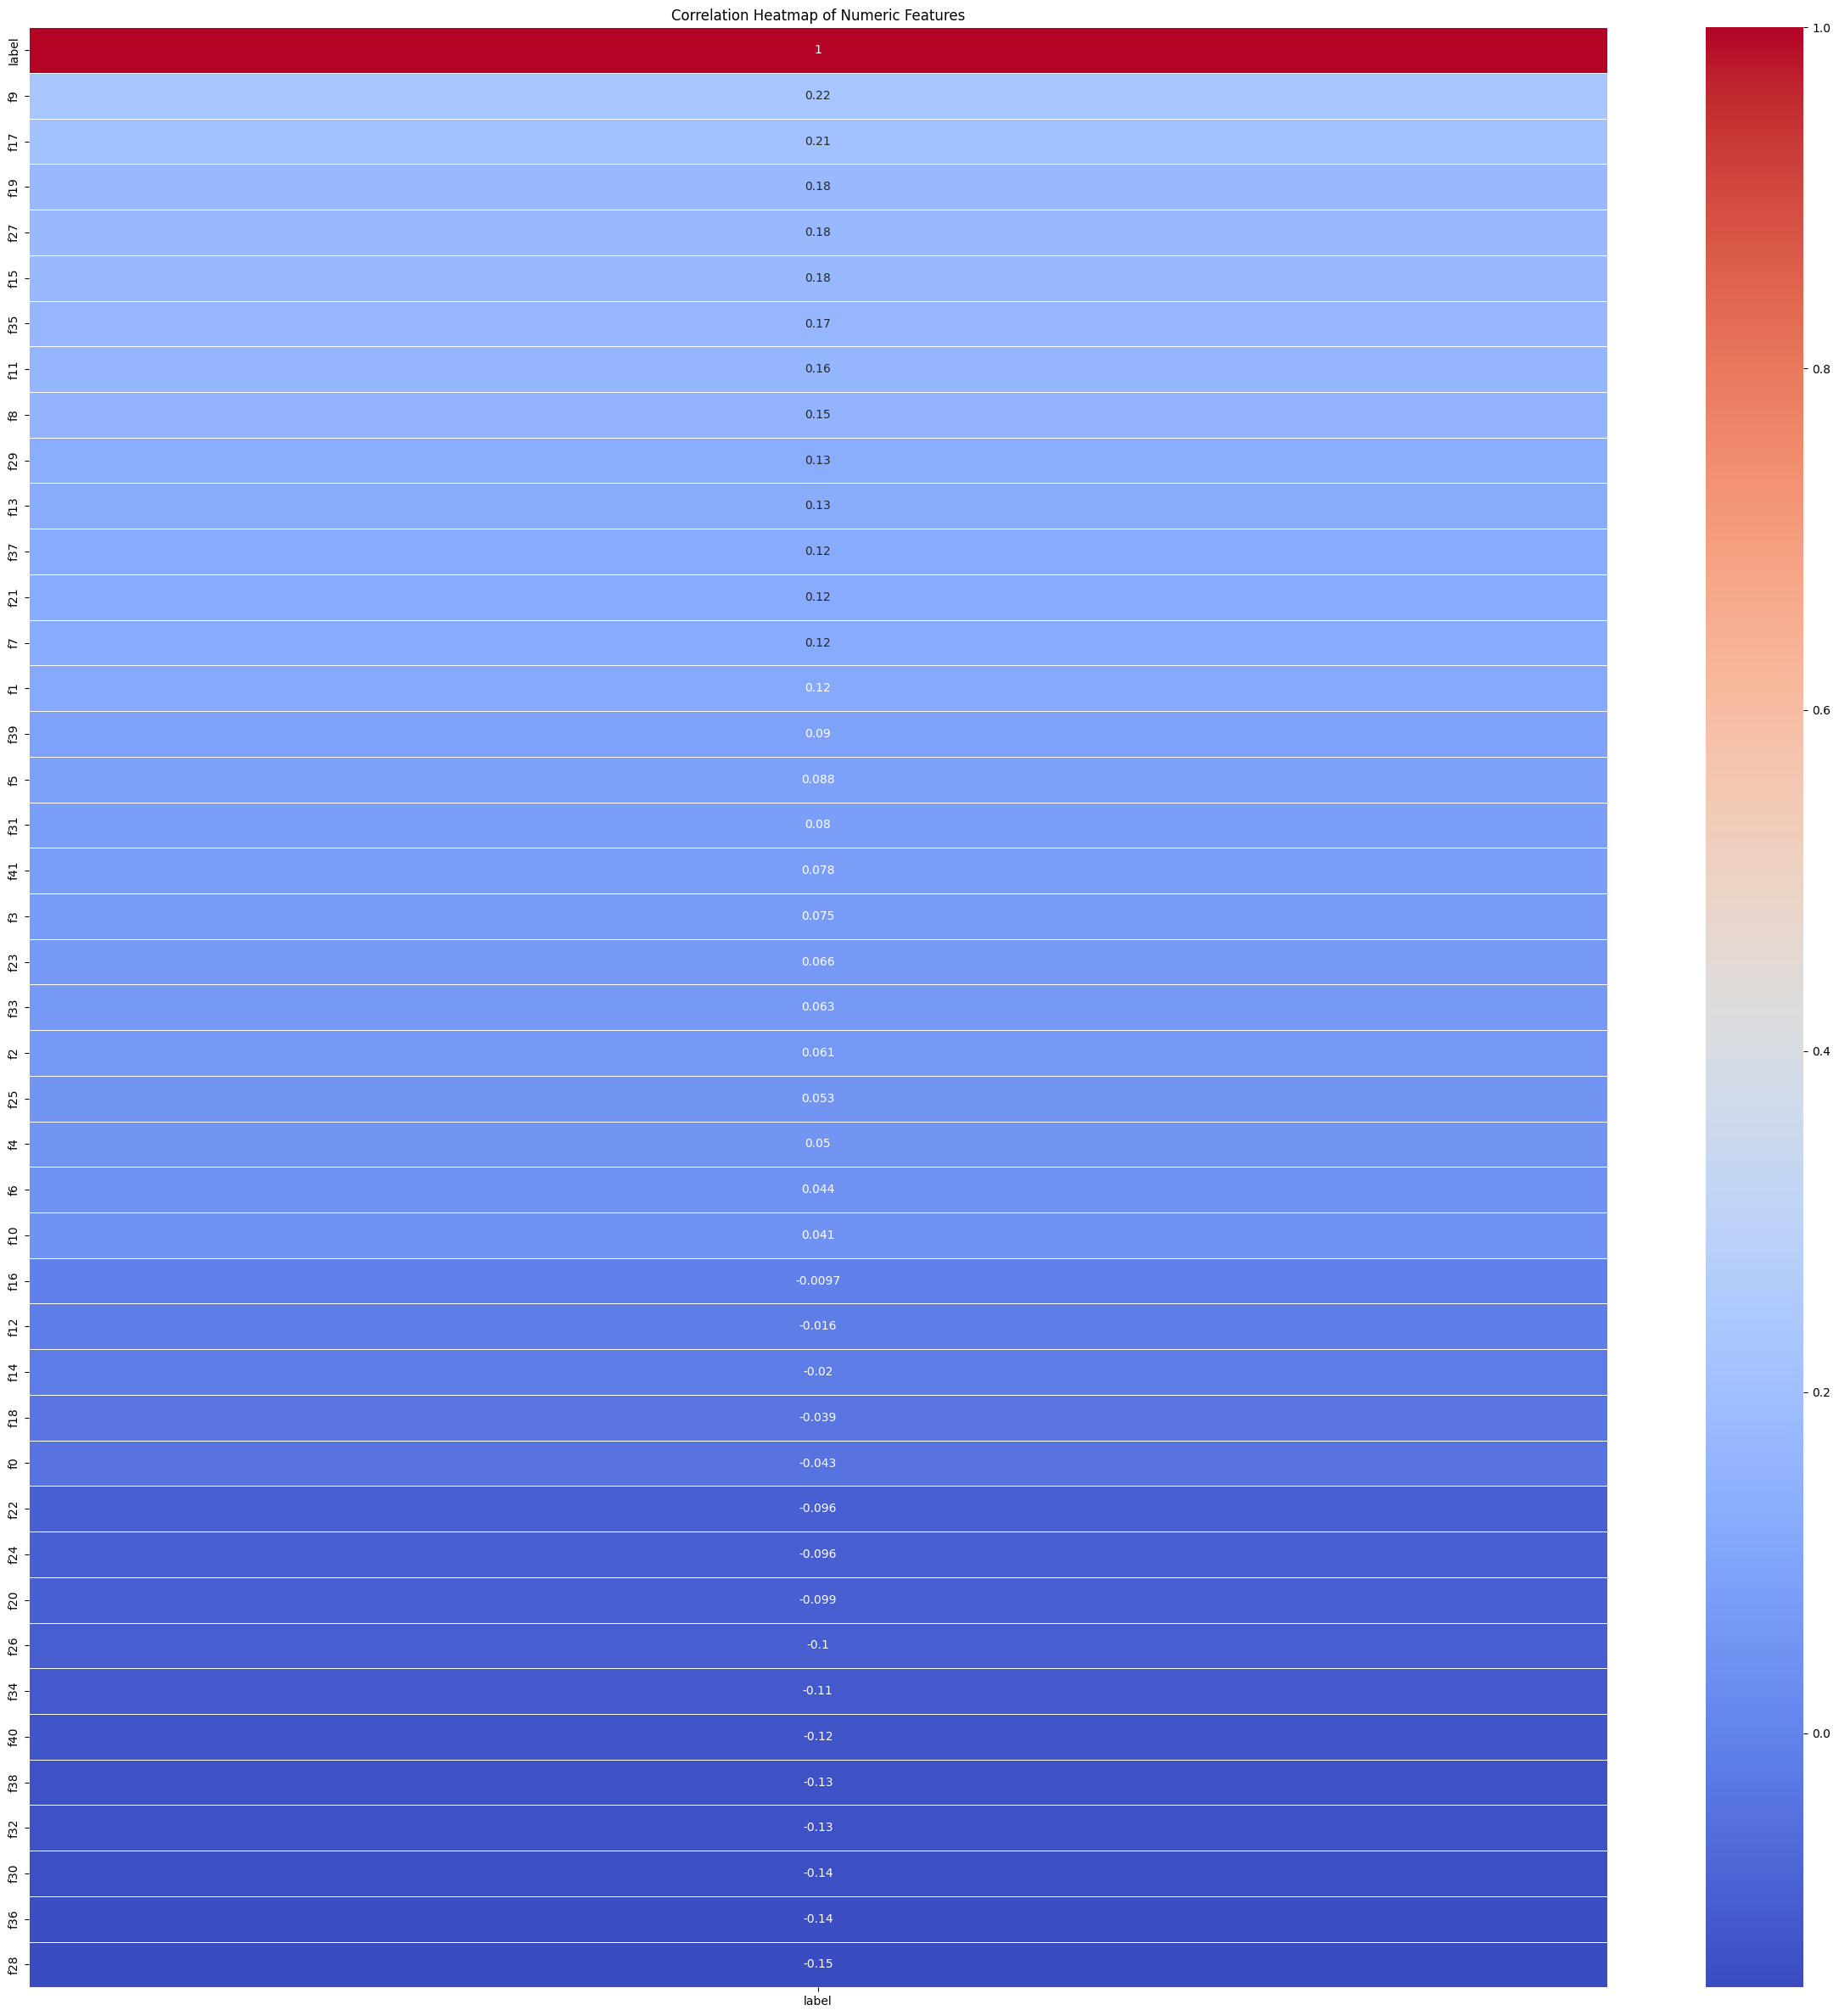

In [81]:

plt.figure(figsize=(30, 30))

corr = df[df.columns].corr()
corr_with_rating = corr['label'].sort_values(ascending=False).to_frame()

sns.heatmap(corr_with_rating, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Model Training && Evaluation

In [8]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
  
)
from sklearn.pipeline import Pipeline


In [ ]:

models = [  ('lr', LogisticRegression(max_iter=10000, solver='lbfgs')),
            ('gnb', GaussianNB()),
            ('mnb',MultinomialNB()),
            ('cnb',ComplementNB()),
            ('bnb',BernoulliNB()),
            ('knn', KNeighborsClassifier(n_neighbors=20)),
            ('rf', RandomForestClassifier(n_estimators=500,random_state=42)),
            ('dt', DecisionTreeClassifier(max_depth=500,random_state=42)),
            ('ridge', RidgeClassifier()),
            ("svc_rbf", SVC(kernel="rbf", probability=True)),
            ("svc", SVC(probability=True)),

            ("svc_linear", SVC(kernel="linear", probability=True)),

            # Neural Network
            ('mlp', MLPClassifier(max_iter=10000)),
            ('lda', LinearDiscriminantAnalysis()),
            ('qda', QuadraticDiscriminantAnalysis()),
]

ensemble_models = [
("Pasting", BaggingClassifier(
        estimator=models[7][1], #Bagging should use simple weak learner
        n_estimators=500,
        random_state=42,
        bootstrap=False # pasting classifier (no replacement)
    )),
    ("Bagging", BaggingClassifier(
        estimator=models[7][1], #Bagging should use simple weak learner
        n_estimators=500,
        random_state=42,
        bootstrap=True
    )),

    ("GradientBoosting", GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )),

    ("Voting", VotingClassifier(
        estimators=[
            ("lr", models[0][1]),
            ("rf", models[6][1]),
            ("svc_linear", models[11][1]),
            
        ],
        voting='soft'   # better than hard
    )),

    ("Stacking", StackingClassifier(
        estimators=[
             ("lr", models[0][1]),
             ("rf", models[6][1]),
             ("svc_linear", models[11][1]),
             ("ridge", models[8][1])
        ],
        final_estimator=LogisticRegression(),
        passthrough=False
    )),
    ("AdaBoost", AdaBoostClassifier(
        estimator=models[7][1],  # using dt as base estimator
        n_estimators=500,
        random_state=42
        ))


            ]

In [10]:
def eval_model(grid, X_train, y_train, X_val, y_val):
    
    y_pred_train = grid.predict(X_train)
    y_pred_val = grid.predict(X_val)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    return acc_train, acc_val

---------------------------------------
lr Accuracy: (0.975983436853002, 0.9814126394052045)
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        74
           1       0.98      0.98      0.98        81
           2       1.00      0.96      0.98        76
           3       0.92      0.99      0.95        68

    accuracy                           0.97       299
   macro avg       0.97      0.97      0.97       299
weighted avg       0.97      0.97      0.97       299



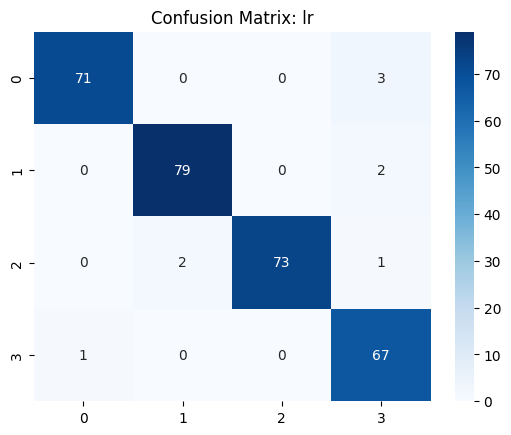

---------------------------------------
gnb Accuracy: (0.686128364389234, 0.7137546468401487)
              precision    recall  f1-score   support

           0       0.63      0.78      0.70        74
           1       0.85      0.70      0.77        81
           2       0.75      0.75      0.75        76
           3       0.53      0.50      0.52        68

    accuracy                           0.69       299
   macro avg       0.69      0.68      0.68       299
weighted avg       0.70      0.69      0.69       299



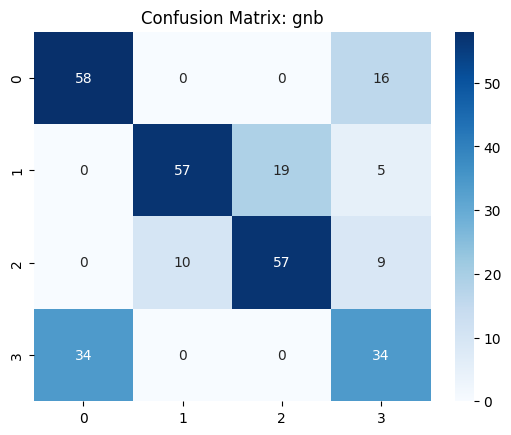

Error processing in model mnb: Negative values in data passed to MultinomialNB (input X).
skipping...
Error processing in model cnb: Negative values in data passed to ComplementNB (input X).
skipping...
---------------------------------------
bnb Accuracy: (0.6579710144927536, 0.6840148698884758)
              precision    recall  f1-score   support

           0       0.57      0.65      0.61        74
           1       0.86      0.73      0.79        81
           2       0.78      0.67      0.72        76
           3       0.52      0.62      0.56        68

    accuracy                           0.67       299
   macro avg       0.68      0.67      0.67       299
weighted avg       0.69      0.67      0.68       299



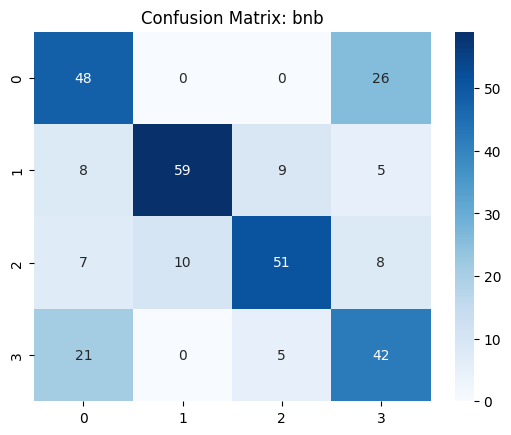

---------------------------------------
knn Accuracy: (0.9072463768115943, 0.9033457249070632)
              precision    recall  f1-score   support

           0       0.88      0.89      0.89        74
           1       0.91      0.98      0.94        81
           2       0.99      0.89      0.94        76
           3       0.85      0.85      0.85        68

    accuracy                           0.91       299
   macro avg       0.91      0.90      0.90       299
weighted avg       0.91      0.91      0.91       299



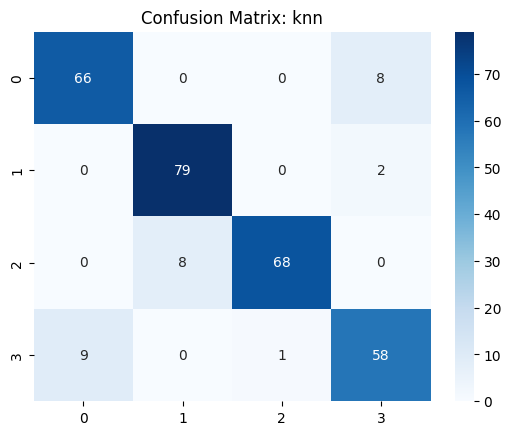

---------------------------------------
rf Accuracy: (0.9950310559006211, 0.9702602230483272)
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        74
           1       0.98      0.98      0.98        81
           2       1.00      0.97      0.99        76
           3       0.97      0.97      0.97        68

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



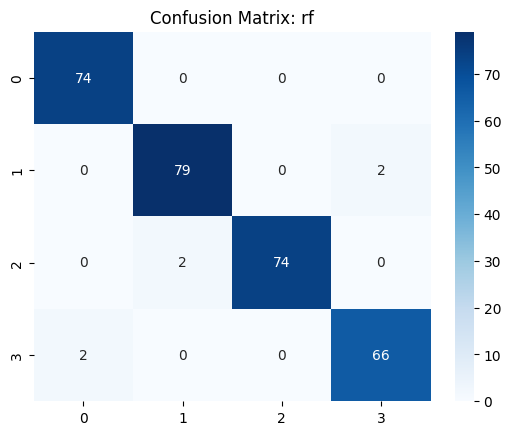

---------------------------------------
dt Accuracy: (0.9950310559006211, 0.9628252788104089)
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        74
           1       0.97      0.94      0.96        81
           2       0.94      0.96      0.95        76
           3       0.87      0.91      0.89        68

    accuracy                           0.93       299
   macro avg       0.93      0.93      0.93       299
weighted avg       0.93      0.93      0.93       299



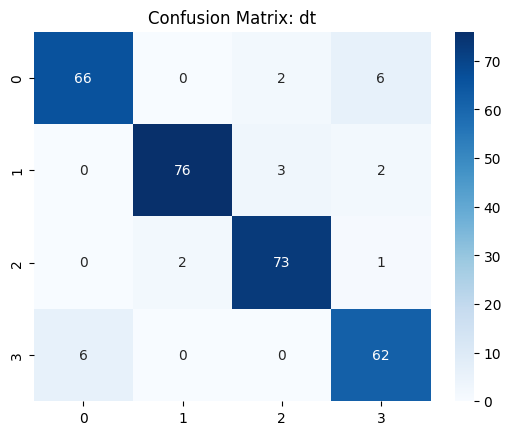

---------------------------------------
ridge Accuracy: (0.9507246376811594, 0.9702602230483272)
              precision    recall  f1-score   support

           0       0.99      0.95      0.97        74
           1       0.91      0.98      0.94        81
           2       1.00      0.87      0.93        76
           3       0.89      0.99      0.94        68

    accuracy                           0.94       299
   macro avg       0.95      0.94      0.94       299
weighted avg       0.95      0.94      0.94       299



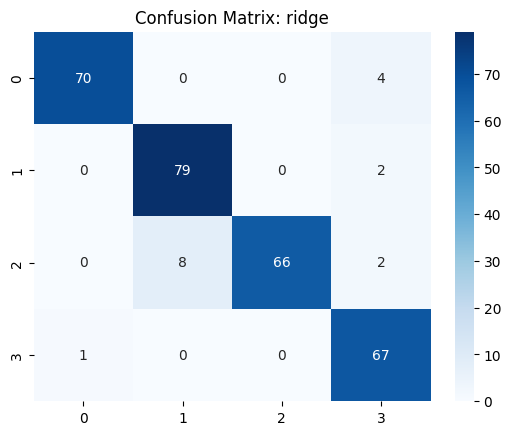

---------------------------------------
svc_rbf Accuracy: (0.9718426501035197, 0.9739776951672863)
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       0.96      0.98      0.97        81
           2       1.00      0.96      0.98        76
           3       0.94      1.00      0.97        68

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



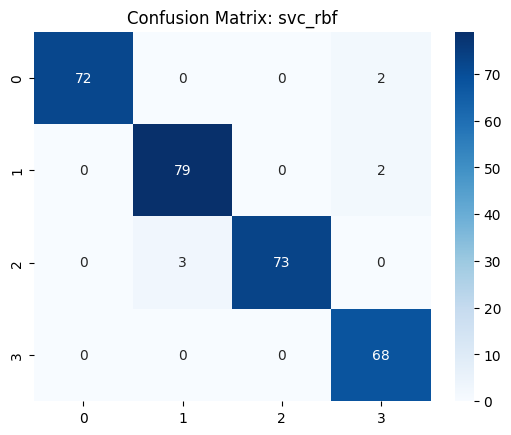

---------------------------------------
svc Accuracy: (0.9718426501035197, 0.9739776951672863)
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       0.96      0.98      0.97        81
           2       1.00      0.96      0.98        76
           3       0.94      1.00      0.97        68

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



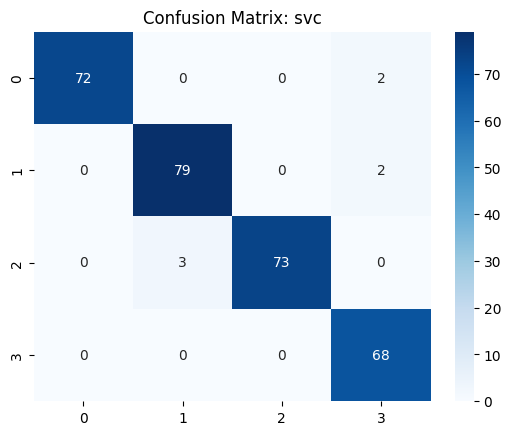

---------------------------------------
svc_linear Accuracy: (0.9826086956521739, 0.9851301115241635)
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        74
           1       0.99      0.98      0.98        81
           2       1.00      0.99      0.99        76
           3       0.94      0.99      0.96        68

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



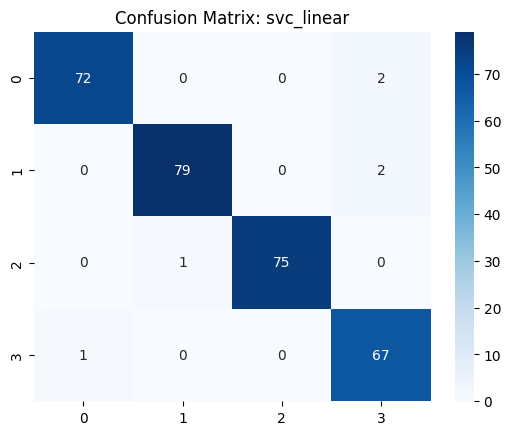

---------------------------------------
mlp Accuracy: (0.9925465838509316, 0.9962825278810409)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       0.96      1.00      0.98        81
           2       1.00      1.00      1.00        76
           3       1.00      0.96      0.98        68

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



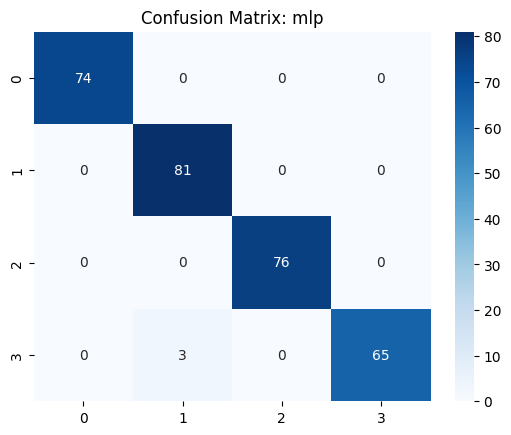

---------------------------------------
lda Accuracy: (0.9631469979296067, 0.9739776951672863)
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        74
           1       0.93      0.98      0.95        81
           2       1.00      0.91      0.95        76
           3       0.92      0.97      0.94        68

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.96      0.95      0.95       299



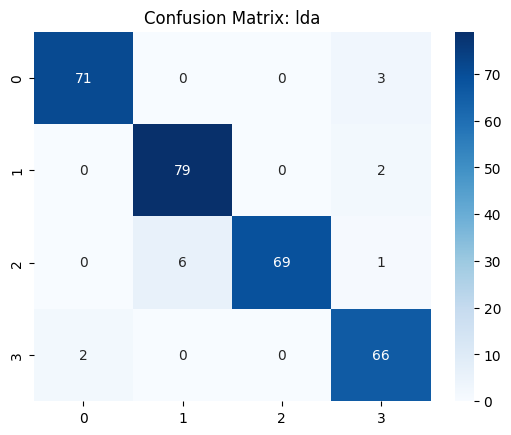

Error processing in model qda: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
skipping...
---------------------------------------
Pasting Accuracy: (0.9950310559006211, 0.9776951672862454)
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        74
           1       0.97      0.95      0.96        81
           2       0.95      0.96      0.95        76
           3       0.91      0.93      0.92        68

    accuracy                           0.94       299
   macro avg       0.94      0.94      0.94       299
weighted avg       0.94      0.94      0.94       299



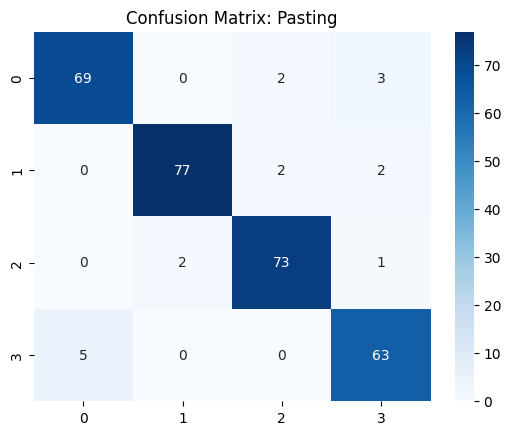

---------------------------------------
Bagging Accuracy: (0.9950310559006211, 0.9851301115241635)
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        74
           1       0.97      0.95      0.96        81
           2       0.97      0.96      0.97        76
           3       0.92      0.99      0.95        68

    accuracy                           0.96       299
   macro avg       0.96      0.96      0.96       299
weighted avg       0.96      0.96      0.96       299



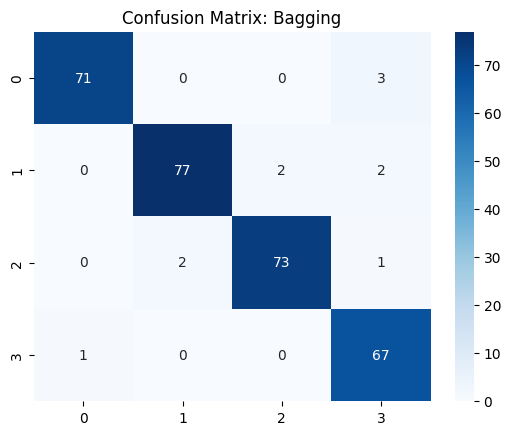

---------------------------------------
GradientBoosting Accuracy: (0.9950310559006211, 0.9851301115241635)
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       0.99      0.98      0.98        81
           2       1.00      0.97      0.99        76
           3       0.93      1.00      0.96        68

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



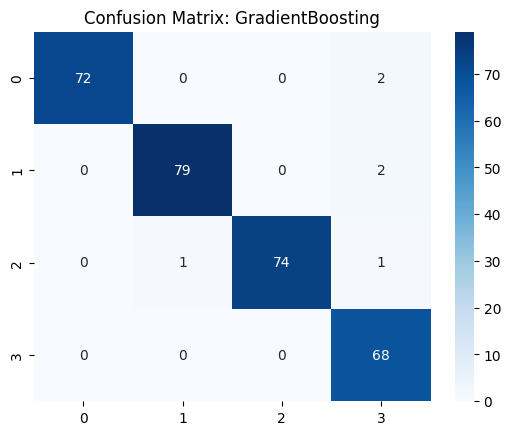

Error processing in model Voting: 'RidgeClassifier' object has no attribute 'predict_proba'
skipping...
---------------------------------------
Stacking Accuracy: (0.9946169772256729, 0.9925650557620818)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      0.98      0.99        81
           2       1.00      1.00      1.00        76
           3       0.97      1.00      0.99        68

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



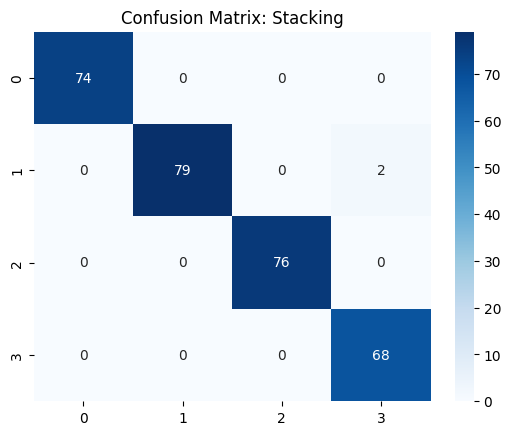

---------------------------------------
AdaBoost Accuracy: (0.9937888198757764, 0.9776951672862454)
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        74
           1       0.94      0.99      0.96        81
           2       0.99      0.96      0.97        76
           3       0.92      0.90      0.91        68

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



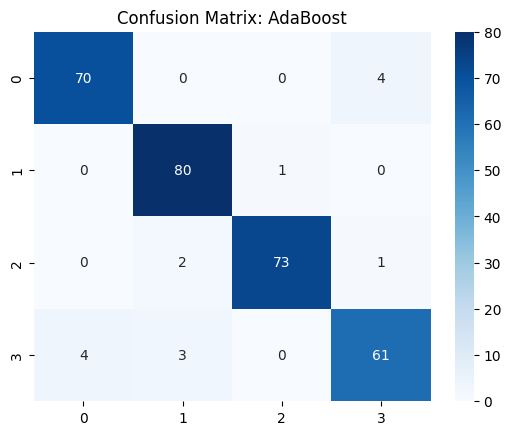

All models processed.


In [11]:
model_accuracies=[]
trained_models=[]

for modell in models + ensemble_models:
    name, clf = modell


    model = Pipeline([
    ("scaler", scaler),
    (f"{name}", clf)
])
    try:
        model.fit(X_train, y_train)

        y_pred= model.predict(X_test)



        accuracy_tra,accuracy_val = eval_model(model, X_train, y_train, X_val, y_val)
        trained_models.append((name,model))
        model_accuracies.append((name, (accuracy_tra,accuracy_val,accuracy_score(y_test, y_pred))))
   

        print("---------------------------------------")
        print(f"{name} Accuracy:", (accuracy_tra,accuracy_val))
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {name}')
        plt.show()
    except Exception as e:
        print(f"Error processing in model {name}: {e}")
        print("skipping...")
print("All models processed.")


In [12]:
os.makedirs('.\\Pose_Estimation\\models', exist_ok=True)
os.makedirs('.\\Pose_Estimation\\workspace', exist_ok=True)

In [13]:
import pickle

for name, model in trained_models:

  with open(f'.\\Pose_Estimation\\models\\{name}.pkl', 'wb') as f:
         pickle.dump(model, f)
         #print(model)

In [14]:
import joblib
joblib.dump(scaler, '.\\Pose_Estimation\\workspace\\Scaler.pkl')

['.\\Pose_Estimation\\workspace\\Scaler.pkl']

               Model  Accuracy(train)  Accuracy(val)  Accuracy(test)
10               mlp         0.992547       0.996283        0.989967
15          Stacking         0.994617       0.992565        0.993311
14  GradientBoosting         0.995031       0.985130        0.979933
9         svc_linear         0.982609       0.985130        0.979933
13           Bagging         0.995031       0.985130        0.963211
0                 lr         0.975983       0.981413        0.969900
12           Pasting         0.995031       0.977695        0.943144
16          AdaBoost         0.993789       0.977695        0.949833
7            svc_rbf         0.971843       0.973978        0.976589
8                svc         0.971843       0.973978        0.976589
11               lda         0.963147       0.973978        0.953177
6              ridge         0.950725       0.970260        0.943144
4                 rf         0.995031       0.970260        0.979933
5                 dt         0.995

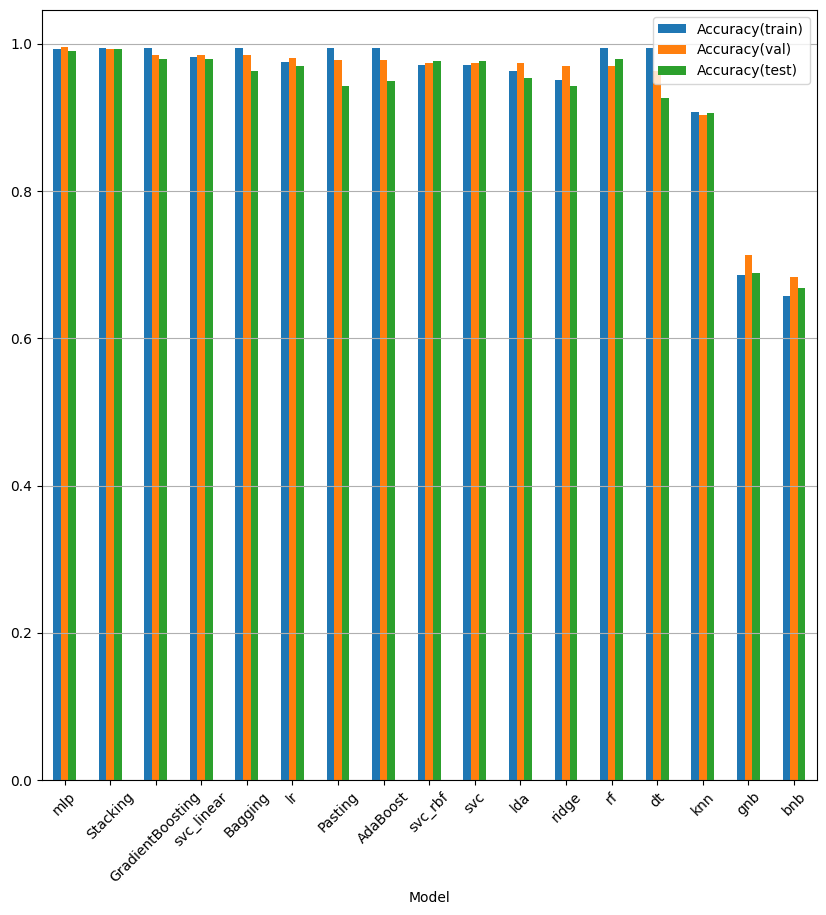

In [15]:
results=[]

i=0
for name,acc in model_accuracies:
    
    results.append((name,acc[0],acc[1],acc[2]))
    i+=1

results = pd.DataFrame(results)
results.columns=['Model','Accuracy(train)','Accuracy(val)','Accuracy(test)']
results.sort_values(by='Accuracy(val)',ascending=False,inplace=True)
print (results)
results.plot.bar(x='Model', y=['Accuracy(train)',"Accuracy(val)",'Accuracy(test)'], figsize=(10, 10))
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

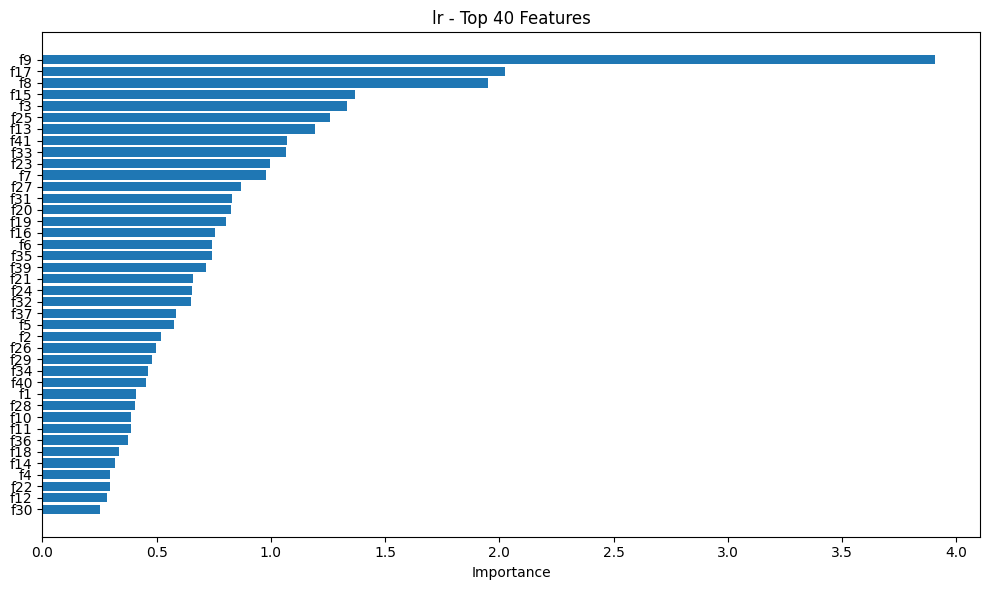

gnb: using permutation importance (slow)...


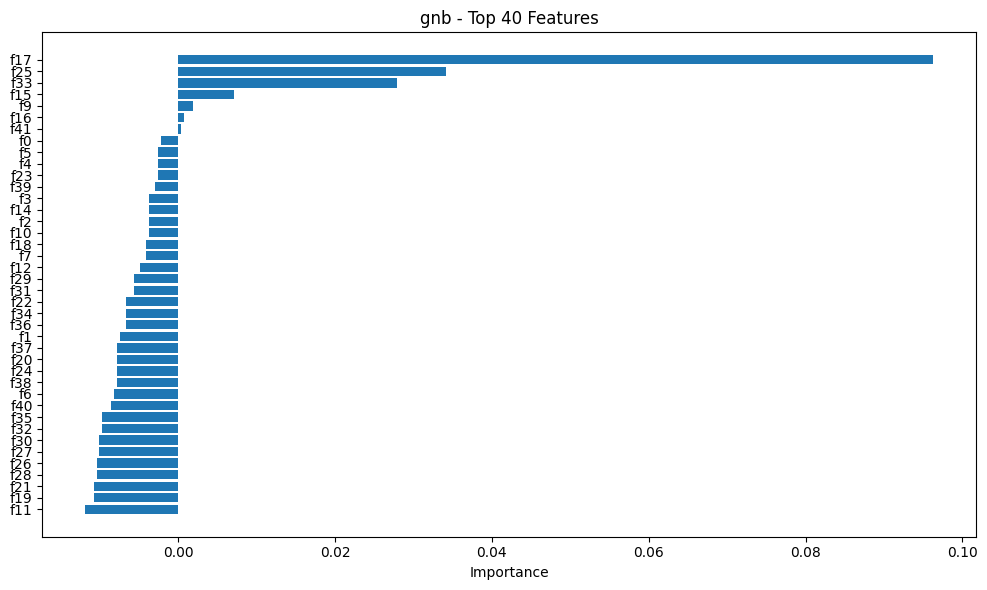

bnb: using permutation importance (slow)...


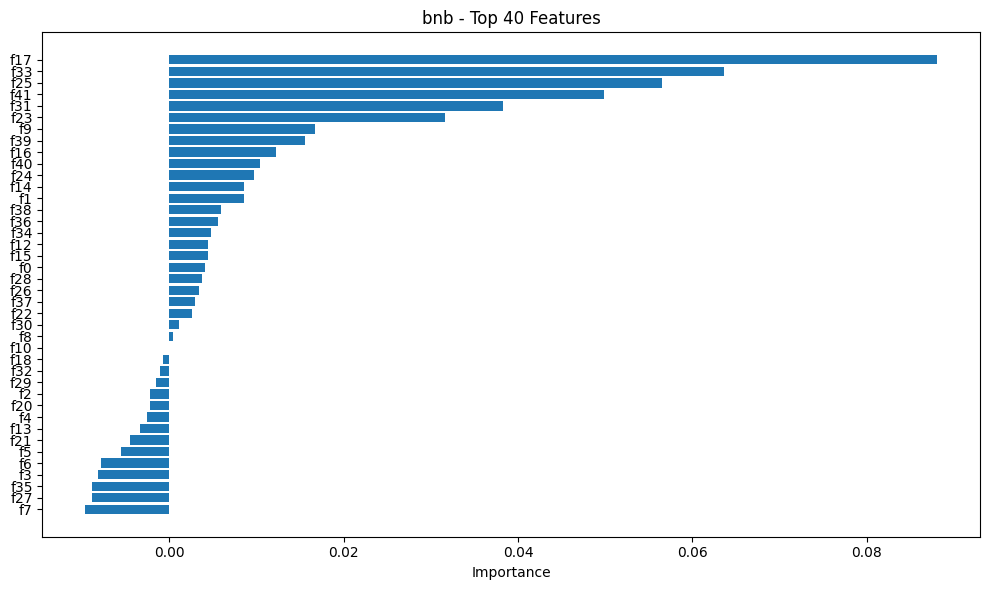

knn: using permutation importance (slow)...


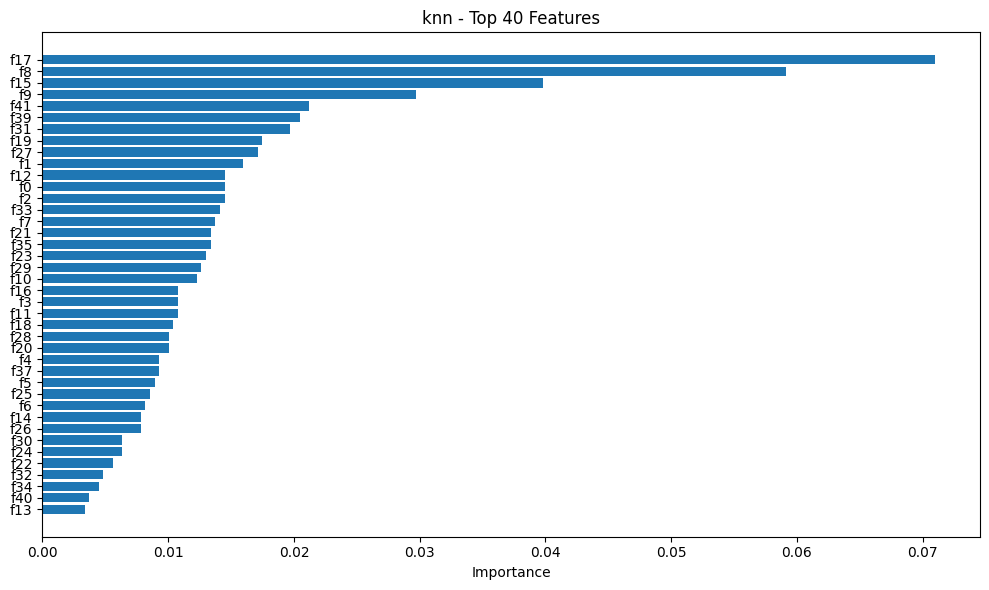

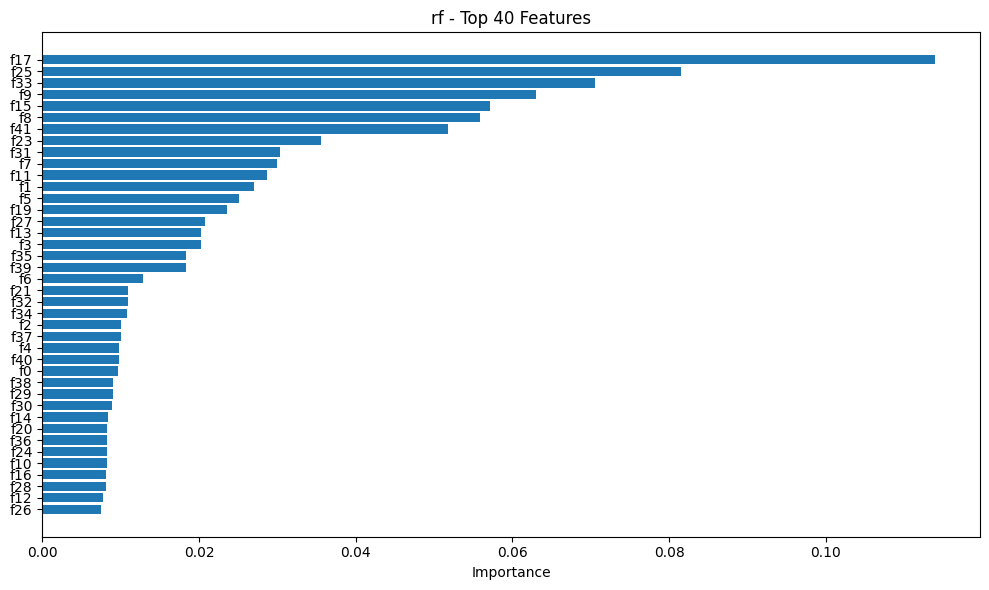

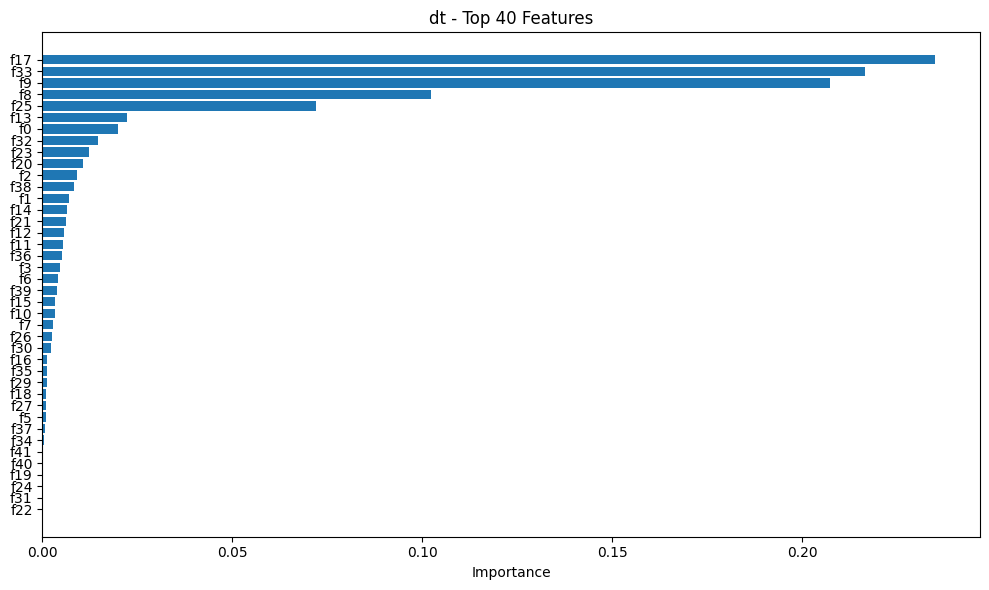

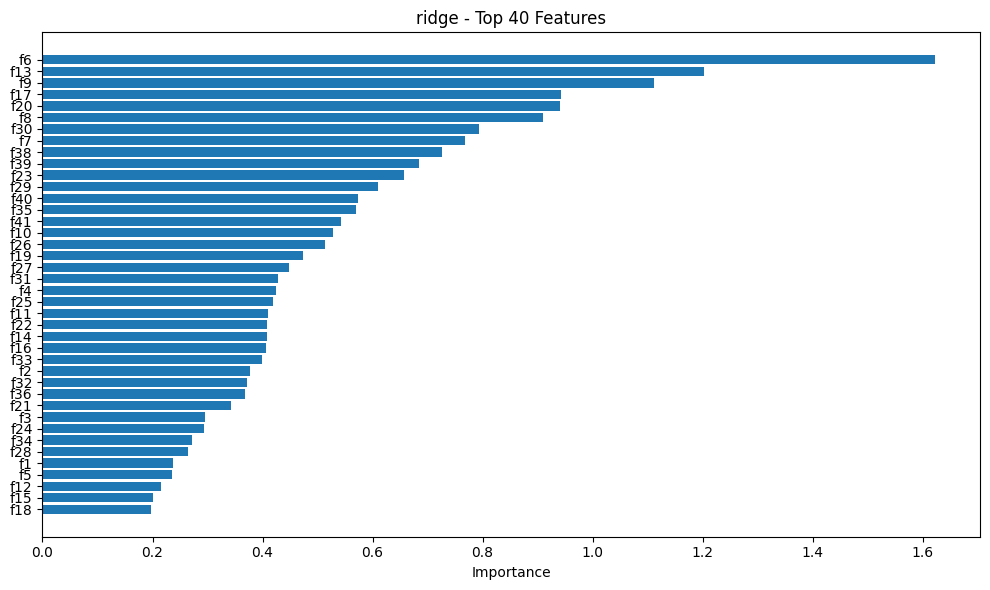

svc_rbf: using permutation importance (slow)...


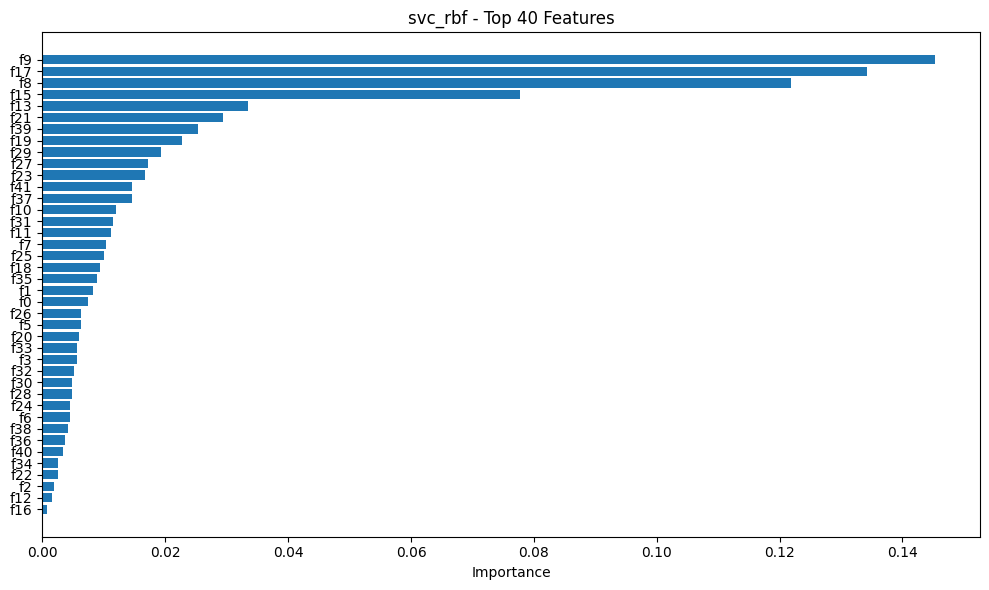

svc: using permutation importance (slow)...


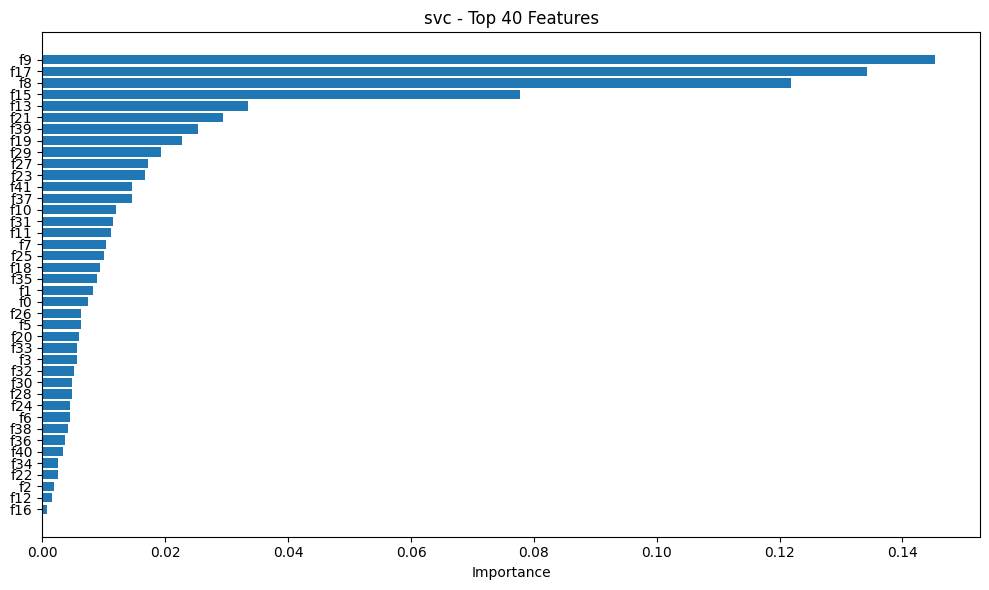

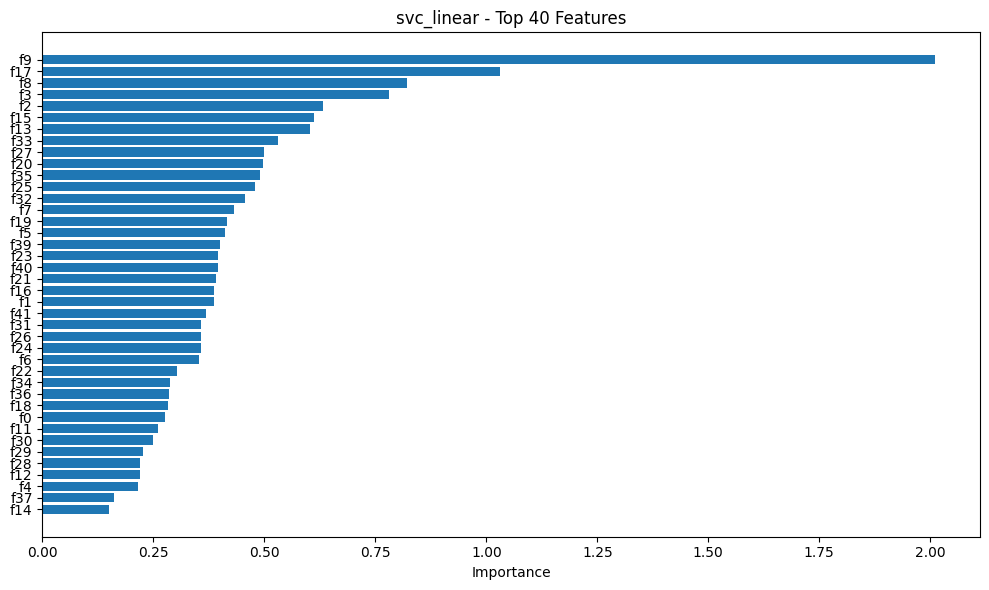

mlp: using permutation importance (slow)...


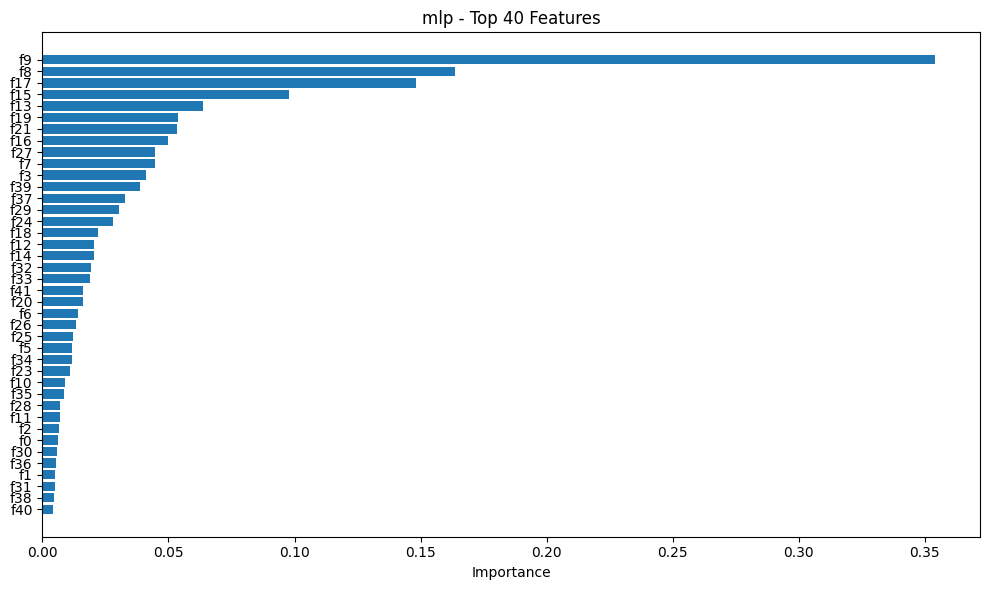

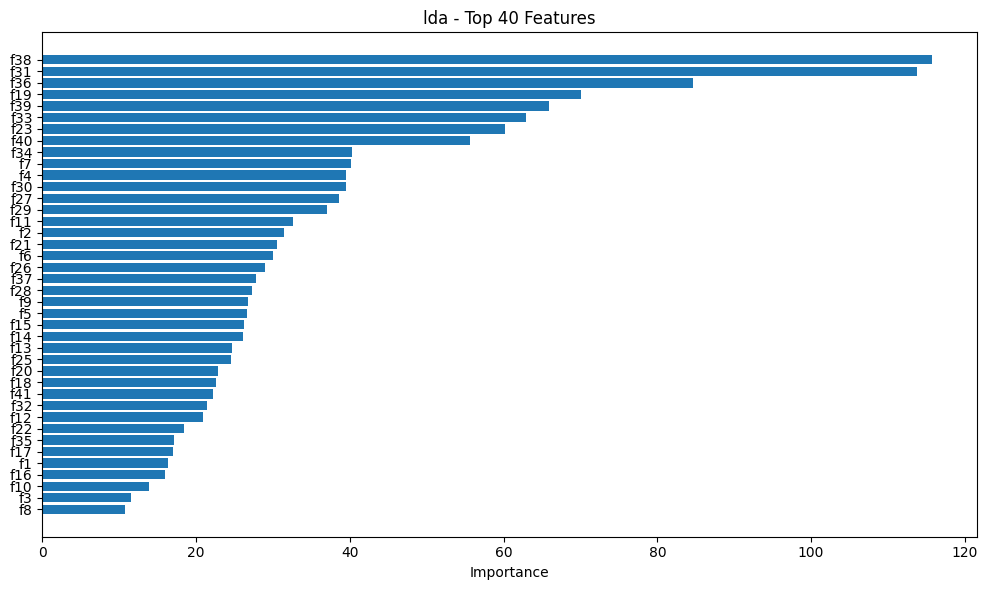

Pasting: using permutation importance (slow)...


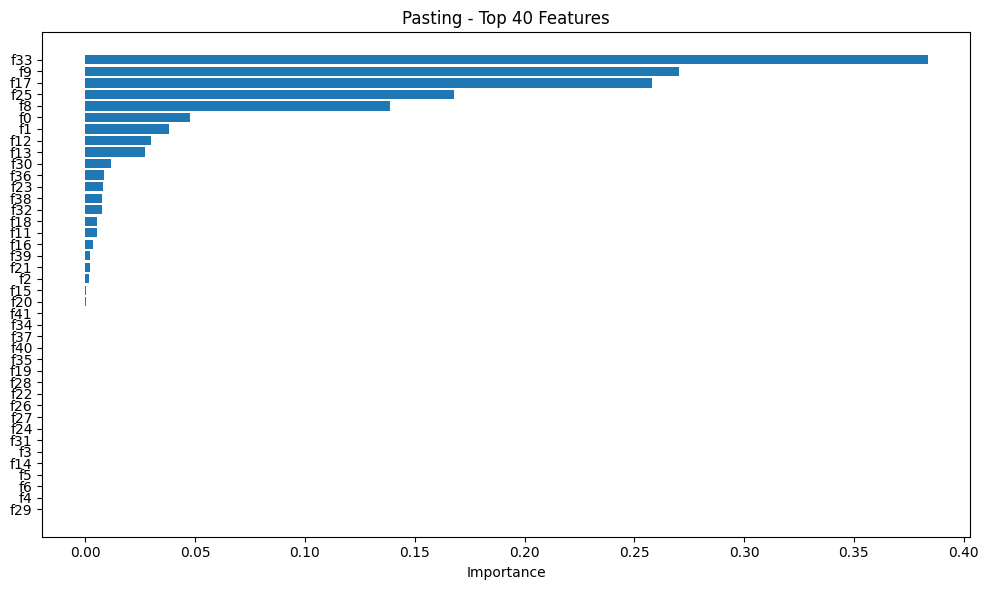

Bagging: using permutation importance (slow)...


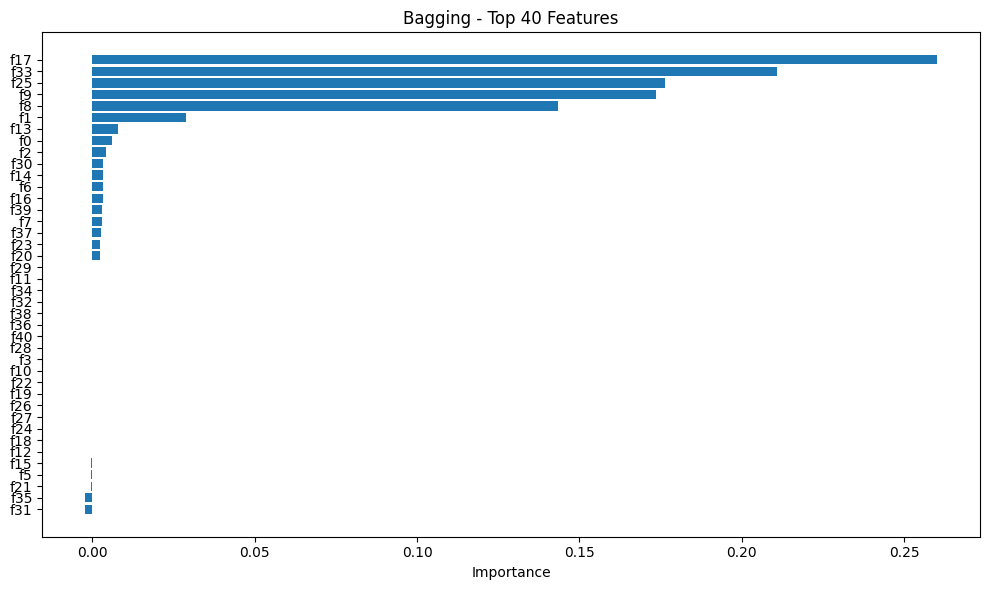

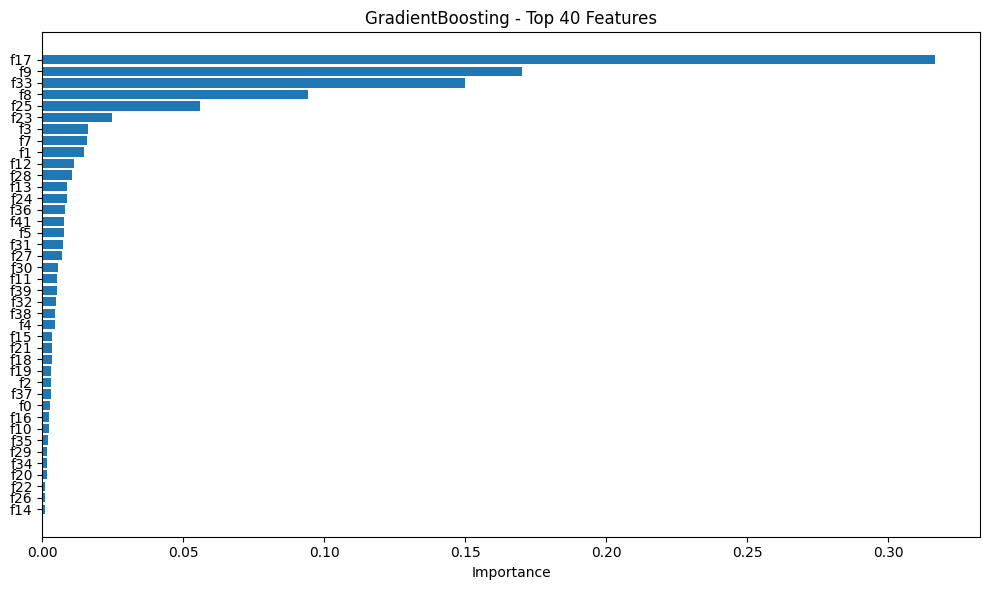

Stacking: using permutation importance (slow)...


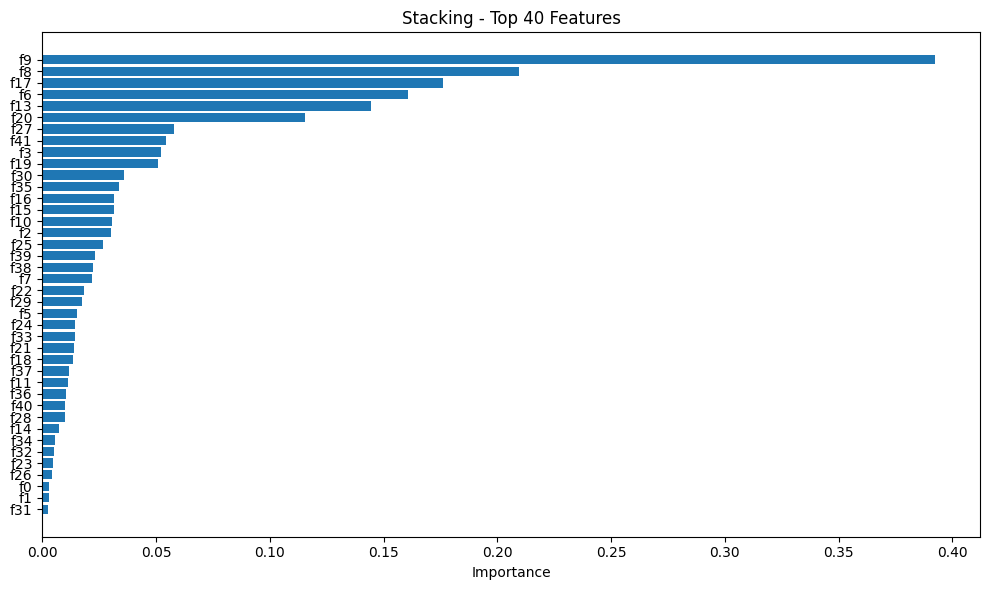

AdaBoost: using permutation importance (slow)...


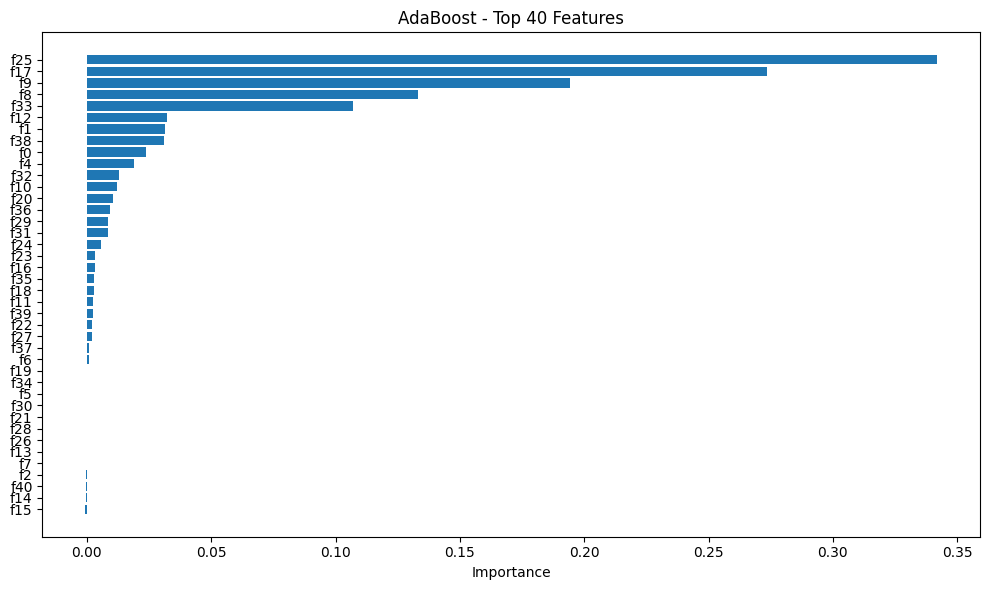

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

def plot_feature_importance(name, model, X, y, feature_names, top_n=20):

   

    importances = None

    # -----------------------------
    # 1. TREE MODELS
    # -----------------------------
    tree_models = (
        "rf",
        "dt",
        "GradientBoosting"
    )

    if name in tree_models:
        importances = model.feature_importances_  # for tree models

    # -----------------------------
    # 2. LINEAR MODELS
    # -----------------------------
    elif hasattr(model, "coef_"): # for linear models like  RidgeClassifier, SVC with linear kernel
        importances = np.abs(model.coef_)

        # multiclass handling
        if importances.ndim > 1:
            importances = importances.mean(axis=0)

    # -----------------------------
    # 3. EVERYTHING ELSE → SAFE FALLBACK
    # -----------------------------
    else:
        print(f"{name}: using permutation importance (slow)...")

        result = permutation_importance( # for ensemble models and others without built-in importance
            model,
            X,
            y,
            n_repeats=10,   # reduced for speed
            random_state=42,
            n_jobs=-1
        )

        importances = result.importances_mean

    # -----------------------------
    # safety check
    # -----------------------------
    importances = np.array(importances)

    if len(importances) != len(feature_names):
        print(f"{name}:  mismatch features vs importance")
        return

    # -----------------------------
    # sort
    # -----------------------------
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_names)[indices], importances[indices])
    plt.title(f"{name} - Top {top_n} Features")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()



for name,clf in trained_models :
    plot_feature_importance(name, clf[1], X_val, y_val, feature_names=data_input.columns, top_n=40)   
    #                                ^ extract model from pipeline

`Here We Knew That Best Model In Generalization is: (LDA)`

In [17]:
for name, clf in trained_models:
  if name=='lda':
    with open('.\\Pose_Estimation\\workspace\\Best_model.txt', 'w') as f:
         f.write(name)

## Real-Time Detection

In [39]:
def real_time():

    import cv2
    import mediapipe as mp
    import numpy as np

    # -----------------------------
    # MEDIAPIPE SETUP
    # -----------------------------
    BaseOptions = mp.tasks.BaseOptions
    HandLandmarker = mp.tasks.vision.HandLandmarker
    HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
    VisionRunningMode = mp.tasks.vision.RunningMode

    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
        running_mode=VisionRunningMode.VIDEO,
        num_hands=1
    )

    landmarker = HandLandmarker.create_from_options(options)

    # -----------------------------
    # CAMERA
    # -----------------------------
    cap = cv2.VideoCapture(0)

    timestamp = 0
    TIME_STEP = 33

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w, _ = frame.shape

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = landmarker.detect_for_video(mp_image, int(timestamp))
        timestamp += TIME_STEP

        label = "No Hand Detected"

        # -----------------------------
        # FEATURE EXTRACTION + PREDICTION
        # -----------------------------
        if result.hand_landmarks:

            hand = result.hand_landmarks[0]

            lm_list = []
            for lm in hand:
                lm_list.extend([lm.x, lm.y]) # only x, y for real-time to reduce noise and improve performance
                #lm_list.extend([lm.x, lm.y, lm.z]) --- IGNORE --

            features = np.array(lm_list).reshape(1, -1)

            # scale + predict
            features = scaler.transform(features)
            #pred = model.predict(features)[0]
            pred = trained_models[11][1].predict(features)[0]
        
            print(f"Classifier: {trained_models[11][0]}")
            # convert label safely
            class_name = str(pred)
            if "label_map" in globals():
                class_name = label_map.get(pred, str(pred))

            label = f"Hand Detected | Class: {class_name}"

            # -----------------------------
            # DRAW LANDMARKS
            # -----------------------------
            for lm in hand:
                x = int(lm.x * w)
                y = int(lm.y * h)
                cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)

        # -----------------------------
        # DISPLAY TEXT
        # -----------------------------
        cv2.putText(
            frame,
            label,
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

        cv2.imshow("Real-Time Hand Sign Recognition", frame)

        if cv2.waitKey(1) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()

In [40]:
real_time()

Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifier: lda
Classifi